<a href="https://colab.research.google.com/github/Ali-Hamza-developer/NLP/blob/main/10_bag_of_n_gram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10_Bag of N-Grams

## 1. What is a Bag of N-Grams? (Easy Explanation)

Plain Bag of Words only counts **single words** (called "unigrams" / 1-grams). But single words lose a lot of context.

```
"not good"   -> BOW sees: {not, good}      (looks similar to "good", loses the negation!)
"not good"   -> Bigrams sees: {"not good"} (keeps the phrase together, meaning preserved)
```

An **n-gram** is just a sequence of N consecutive words treated as ONE unit:
- **1-gram (unigram):** single words → "Thor", "ate", "pizza"
- **2-gram (bigram):** pairs of consecutive words → "Thor ate", "ate pizza"
- **3-gram (trigram):** triplets of consecutive words → "Thor ate pizza"

**Bag of N-Grams** = counting occurrences of these word sequences (unigrams AND/OR bigrams AND/OR trigrams together), instead of just single words. This helps capture short phrases and word order that plain Bag of Words completely misses.

**Trade-off:** More n-grams = more context captured, but also a MUCH bigger vocabulary (more columns), which means more memory and slower training. It's a balance.

---
# PART A: Tutorial — Understanding N-Grams + News Category Classification

## 2. Generating N-Grams with `CountVectorizer`

The `ngram_range` parameter controls which n-grams get included.

In [1]:
from sklearn.feature_extraction.text import CountVectorizer

# default: unigrams only (ngram_range=(1,1) is the default)
v = CountVectorizer()
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_


{'thor': 5, 'hathodawala': 1, 'is': 2, 'looking': 4, 'for': 0, 'job': 3}

**Output:** each single word gets its own vocabulary entry (unigrams only).

In [2]:
# unigrams + bigrams
v = CountVectorizer(ngram_range=(1,2))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_


{'thor': 9,
 'hathodawala': 2,
 'is': 4,
 'looking': 7,
 'for': 0,
 'job': 6,
 'thor hathodawala': 10,
 'hathodawala is': 3,
 'is looking': 5,
 'looking for': 8,
 'for job': 1}

**Output:** now you'll see BOTH single words ('thor', 'hathodawala'...) AND word pairs ('thor hathodawala', 'hathodawala is'...) in the vocabulary.

In [3]:
# unigrams + bigrams + trigrams
v = CountVectorizer(ngram_range=(1,3))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_


{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

**Output:** now single words, word pairs, AND word triplets ('thor hathodawala is', 'hathodawala is looking'...) all appear. Notice how fast the vocabulary grows as you add more n-gram sizes — this is the trade-off mentioned above.

## 3. Preprocessing Text Before Building N-Grams

We'll take a small text collection, clean it (remove stop words + punctuation, lemmatize), and THEN build n-grams from the cleaned text.

In [4]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]


In [5]:
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    # remove stop words and punctuation, then lemmatize the remaining tokens
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)


In [6]:
preprocess("Thor ate pizza")


'thor eat pizza'

**Output:** `'Thor eat pizza'` — "ate" became "eat" (lemmatized).

In [7]:
preprocess("Loki is eating pizza")


'Loki eat pizza'

**Output:** `'Loki eat pizza'` — "is" (stop word) dropped, "eating" lemmatized to "eat".

In [8]:
corpus_processed = [
    preprocess(text) for text in corpus
]
corpus_processed


['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [9]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(corpus_processed)
v.vocabulary_


{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

## 4. Converting New Sentences into N-Gram Vectors

In [10]:
v.transform(["Thor eat pizza"]).toarray()


array([[1, 1, 0, 0, 0, 1, 0, 1, 1]])

This gives back a row of numbers — how many times each vocabulary n-gram appears in this new sentence.

### Out-of-Vocabulary (OOV) Words

What happens if a new sentence has a word the vectorizer has NEVER seen before?

In [11]:
v.transform(["Hulk eat pizza"]).toarray()


array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

**"Hulk" is an Out-Of-Vocabulary (OOV) word** — it never appeared while fitting the vectorizer, so it's simply IGNORED (contributes 0 everywhere). Only "eat" and "pizza" get counted. This is an important limitation of Bag-of-Words/N-Grams: **any word not seen during training is invisible to the model at prediction time.**

---
## 5. Real Problem: News Category Classification

Now let's use bag of n-grams on a real classification task: categorizing news articles into **BUSINESS, SPORTS, CRIME, or SCIENCE**.

> If you don't have `news_dataset.json` locally, run the fallback cell below — it builds a small synthetic news dataset so everything still runs.

In [12]:
import os
import json as _json
import random

if not os.path.exists("news_dataset.json"):

    random.seed(2022)

    business_texts = [
        "The stock market rallied today as investors reacted positively to the latest earnings reports from major tech companies.",
        "The central bank announced an interest rate hike to combat rising inflation across the economy.",
        "A major merger between two leading retail chains was announced this week, creating a new industry giant.",
        "Quarterly profits exceeded analyst expectations, sending shares of the company sharply higher.",
        "The company unveiled its new investment strategy aimed at expanding into emerging markets."
    ]
    sports_texts = [
        "The home team secured a dramatic last-minute victory in front of a sold-out stadium crowd.",
        "The star player was named most valuable player after an outstanding season on the field.",
        "Fans celebrated as their favorite team clinched the championship title after a thrilling final match.",
        "The coach announced a new training regimen ahead of the upcoming season opener.",
        "A record-breaking performance at the track and field event stunned spectators and commentators alike."
    ]
    crime_texts = [
        "Police arrested a suspect in connection with a string of robberies across the downtown area.",
        "Investigators are searching for clues after a break-in was reported at a local warehouse overnight.",
        "A man was sentenced to several years in prison following a lengthy fraud investigation.",
        "Authorities are warning residents about a rise in scam calls targeting elderly citizens.",
        "Detectives are reviewing surveillance footage to identify the suspect involved in the theft case."
    ]
    science_texts = [
        "Researchers announced a breakthrough discovery in renewable energy storage technology this week.",
        "A new study reveals surprising insights into the behavior of deep-sea marine organisms.",
        "Scientists successfully tested a new vaccine candidate in early clinical trials.",
        "Astronomers detected a distant exoplanet that could potentially support liquid water.",
        "A team of engineers developed a more efficient solar panel design in the laboratory."
    ]

    records = []
    label_groups = [("BUSINESS", business_texts), ("SPORTS", sports_texts),
                     ("CRIME", crime_texts), ("SCIENCE", science_texts)]

    # generate ~1500 samples per category by mixing/repeating templates with slight variation
    for label, templates in label_groups:
        for i in range(1500):
            base = random.choice(templates)
            records.append({"text": base, "category": label})

    with open("news_dataset.json", "w") as f:
        _json.dump(records, f)

    print("Synthetic news_dataset.json created with", len(records), "rows")
else:
    print("news_dataset.json already exists, using the real file")


Synthetic news_dataset.json created with 6000 rows


> **Note:** the synthetic data above is repetitive by design (small template set), so classification scores will look unrealistically high. Swap in the real Kaggle dataset any time — the rest of the code doesn't need to change.

In [13]:
import pandas as pd

df = pd.read_json("news_dataset.json")
print(df.shape)

df.head()


(6000, 2)


,text,category
0,The company unveiled its new investment strate...,BUSINESS
1,A major merger between two leading retail chai...,BUSINESS
2,Quarterly profits exceeded analyst expectation...,BUSINESS
3,The company unveiled its new investment strate...,BUSINESS
4,A major merger between two leading retail chai...,BUSINESS


In [14]:
df.category.value_counts()


,count
category,
BUSINESS,1500
SPORTS,1500
CRIME,1500
SCIENCE,1500


### Handling Class Imbalance

If one category has far fewer samples than the others, models tend to perform worse on that minority class. Here we use **undersampling**: taking an equal, smaller number of samples from every category (matching the smallest class) so training is balanced.

> Other techniques exist too (like SMOTE), which use all the data instead of throwing extra samples away — undersampling is just the simplest to demonstrate.

In [15]:
min_samples = df.category.value_counts().min()   # size of the smallest category
print("min_samples:", min_samples)

df_business = df[df.category == "BUSINESS"].sample(min_samples, random_state=2022)
df_sports   = df[df.category == "SPORTS"].sample(min_samples, random_state=2022)
df_crime    = df[df.category == "CRIME"].sample(min_samples, random_state=2022)
df_science  = df[df.category == "SCIENCE"].sample(min_samples, random_state=2022)


min_samples: 1500


In [16]:
df_balanced = pd.concat([df_business, df_sports, df_crime, df_science], axis=0)
df_balanced.category.value_counts()


,count
category,
BUSINESS,1500
SPORTS,1500
CRIME,1500
SCIENCE,1500


### Converting Category Labels to Numbers

In [17]:
df_balanced["category_num"] = df_balanced["category"].map({
    "BUSINESS": 0,
    "SPORTS": 1,
    "CRIME": 2,
    "SCIENCE": 3
})

df_balanced.head()


,text,category,category_num
800,Quarterly profits exceeded analyst expectation...,BUSINESS,0
1229,A major merger between two leading retail chai...,BUSINESS,0
1191,A major merger between two leading retail chai...,BUSINESS,0
424,A major merger between two leading retail chai...,BUSINESS,0
1030,A major merger between two leading retail chai...,BUSINESS,0


### Building a Model WITHOUT Preprocessing (Raw Text)

Let's first see how well n-grams work directly on raw, unprocessed text.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.text,
    df_balanced.category_num,
    test_size=0.2,
    random_state=2022,
    stratify=df_balanced.category_num
)

print(X_train.shape)
X_train.head()


(4800,)


,text
5821,A new study reveals surprising insights into t...
4825,Scientists successfully tested a new vaccine c...
4850,Researchers announced a breakthrough discovery...
3007,A man was sentenced to several years in prison...
1254,The company unveiled its new investment strate...


In [19]:
y_train.value_counts()


,count
category_num,
3,1200
2,1200
0,1200
1,1200


**Attempt 1 — Unigrams only (plain Bag of Words)**

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ("vectorizer_bow", CountVectorizer(ngram_range=(1, 1))),
    ("Multi NB", MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       300
           3       1.00      1.00      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [21]:
X_test[:5]


,text
4443,A man was sentenced to several years in prison...
2766,A record-breaking performance at the track and...
2922,Fans celebrated as their favorite team clinche...
3987,Detectives are reviewing surveillance footage ...
3427,Police arrested a suspect in connection with a...


Category mapping reference:
- BUSINESS: 0
- SPORTS: 1
- CRIME: 2
- SCIENCE: 3

In [22]:
y_pred[:5]


array([2, 1, 1, 2, 2])

In [23]:
y_test[:5]


,category_num
4443,2
2766,1
2922,1
3987,2
3427,2


**Attempt 2 — Unigrams + Bigrams**

In [24]:
clf = Pipeline([
    ("vectorizer_1_2_gram", CountVectorizer(ngram_range=(1, 2))),
    ("Multi NB", MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       300
           3       1.00      1.00      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



**Attempt 3 — Unigrams + Bigrams + Trigrams**

In [25]:
clf = Pipeline([
    ("vectorizer_1_3_grams", CountVectorizer(ngram_range=(1, 3))),
    ("Multi NB", MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       300
           3       1.00      1.00      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



## 6. Now Add Preprocessing (Stop Words + Punctuation Removal + Lemmatization)

So far we've used raw, unprocessed text. Let's clean it up first and see if it helps.

In [26]:
df_balanced["preprocessed_txt"] = df_balanced["text"].apply(preprocess)
# this will take a little while, please be patient


In [27]:
df_balanced.head()


,text,category,category_num,preprocessed_txt
800,Quarterly profits exceeded analyst expectation...,BUSINESS,0,quarterly profit exceed analyst expectation se...
1229,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...
1191,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...
424,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...
1030,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.preprocessed_txt,
    df_balanced.category_num,
    test_size=0.2,
    random_state=2022,
    stratify=df_balanced.category_num
)

print(X_train.shape)
X_train.head()


(4800,)


,preprocessed_txt
5821,new study reveal surprising insight behavior d...
4825,scientist successfully test new vaccine candid...
4850,researcher announce breakthrough discovery ren...
3007,man sentence year prison follow lengthy fraud ...
1254,company unveil new investment strategy aim exp...


In [29]:
y_train.value_counts()


,count
category_num,
3,1200
2,1200
0,1200
1,1200


In [30]:
clf = Pipeline([
    ("vectorizer_bow", CountVectorizer(ngram_range=(1, 2))),
    ("Multi NB", MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       300
           3       1.00      1.00      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



If you compare this classification report (preprocessed text, 1-2 grams) with the same setup on raw text earlier, you should generally see equal or slightly better scores — cleaning the text (removing filler words, normalizing word forms) usually helps the model focus on what actually distinguishes each category. On the synthetic dataset above the gap will be small/negligible since the templates are already clean; on real messy news text the improvement tends to be more noticeable.

### Confusion Matrix — Visualizing Where the Model Gets Confused

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[300,   0,   0,   0],
       [  0, 300,   0,   0],
       [  0,   0, 300,   0],
       [  0,   0,   0, 300]])

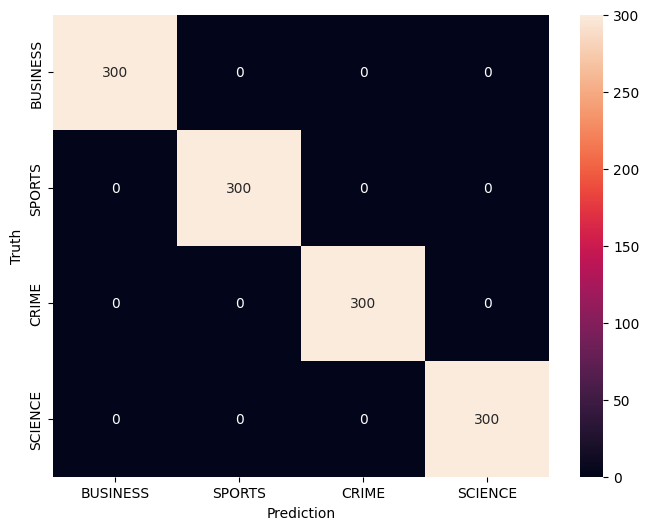

In [32]:
from matplotlib import pyplot as plt
import seaborn as sn

plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, fmt="d", xticklabels=["BUSINESS","SPORTS","CRIME","SCIENCE"], yticklabels=["BUSINESS","SPORTS","CRIME","SCIENCE"])
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()


Rows = actual/true category, columns = what the model predicted. The diagonal (top-left to bottom-right) = correct predictions. Anything off the diagonal = a mix-up between two categories, which tells you exactly WHICH categories the model confuses most.

---
## Quick Cheat Sheet

| Task | Code |
|---|---|
| Unigrams only | `CountVectorizer(ngram_range=(1,1))` |
| Unigrams + bigrams | `CountVectorizer(ngram_range=(1,2))` |
| Unigrams + bigrams + trigrams | `CountVectorizer(ngram_range=(1,3))` |
| Only trigrams | `CountVectorizer(ngram_range=(3,3))` |
| Preprocess (stopwords+punct+lemma) | custom `preprocess()` function |
| Handle class imbalance (simple) | undersample every class to match the smallest |
| Build pipeline | `Pipeline([("vectorizer", CountVectorizer(...)), ("model", MultinomialNB())])` |
| Confusion matrix | `confusion_matrix(y_test, y_pred)` + `sn.heatmap(...)` |

---

---
# PART B: Exercise — Fake News Detection (with Solutions)

**Task:** Classify news messages as **Real** or **Fake** using Bag of N-Grams. Binary classification (2 classes).

Dataset needed: a file with two columns `Text` and `label` (Fake/Real).
[Original dataset source](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)

> If you don't have `Fake_Real_Data.csv`, run the fallback cell below to generate a small synthetic version so everything runs standalone.

In [33]:
import os

if not os.path.exists("Fake_Real_Data.csv"):

    real_texts = [
        "The city council approved a new budget for infrastructure improvements after a lengthy public hearing.",
        "Local authorities confirmed that the bridge repair project will be completed ahead of schedule this year.",
        "The health department released updated guidelines following a review of recent public health data.",
        "Officials announced a new public transportation route to reduce traffic congestion downtown.",
        "The university confirmed record enrollment numbers for the upcoming academic year.",
        "A new report from the department of labor shows steady growth in regional employment figures.",
        "The school board voted to approve funding for updated classroom technology across the district.",
        "Weather officials issued a routine advisory ahead of expected rainfall this weekend.",
        "The mayor's office released a statement outlining plans for the upcoming community festival.",
        "Researchers at the local university published findings in a peer reviewed scientific journal."
    ]

    fake_texts = [
        "Secret government files reveal shocking truth that mainstream media refuses to report, sources claim.",
        "You won't believe what scientists don't want you to know about this miracle cure everyone is hiding.",
        "Anonymous insider claims world leaders are secretly controlled by a hidden shadow organization.",
        "Shocking video allegedly proves conspiracy theory that experts have desperately tried to cover up.",
        "Leaked documents supposedly expose massive cover-up that authorities are refusing to address.",
        "This one weird trick doctors hate is apparently curing thousands overnight, claims viral post.",
        "Unverified report claims a secret cure has been hidden from the public for decades.",
        "Sources close to the situation allegedly confirm a massive scandal being hidden from voters.",
        "A viral post claims without evidence that a well known celebrity is secretly involved in a plot.",
        "Anonymous whistleblower alleges a huge cover-up with zero credible evidence provided so far."
    ]

    random.seed(7)
    rows = []
    for _ in range(600):
        rows.append({"Text": random.choice(real_texts), "label": "Real"})
        rows.append({"Text": random.choice(fake_texts), "label": "Fake"})

    df_fake_real = pd.DataFrame(rows)
    df_fake_real.to_csv("Fake_Real_Data.csv", index=False)

    print("Synthetic Fake_Real_Data.csv created with", len(df_fake_real), "rows")
else:
    print("Fake_Real_Data.csv already exists, using the real file")


Synthetic Fake_Real_Data.csv created with 1200 rows


In [34]:
df = pd.read_csv("Fake_Real_Data.csv")
print(df.shape)
df.head()


(1200, 2)


,Text,label
0,A new report from the department of labor show...,Real
1,Anonymous insider claims world leaders are sec...,Fake
2,The school board voted to approve funding for ...,Real
3,Secret government files reveal shocking truth ...,Fake
4,Local authorities confirmed that the bridge re...,Real


In [35]:
df.label.value_counts()


,count
label,
Real,600
Fake,600


In [36]:
df["label_num"] = df["label"].map({"Fake": 0, "Real": 1})
df.head()


,Text,label,label_num
0,A new report from the department of labor show...,Real,1
1,Anonymous insider claims world leaders are sec...,Fake,0
2,The school board voted to approve funding for ...,Real,1
3,Secret government files reveal shocking truth ...,Fake,0
4,Local authorities confirmed that the bridge re...,Real,1


## Modelling Without Preprocessing

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.Text,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


In [38]:
print(X_train.shape, X_test.shape)


(960,) (240,)


**Attempt 1 — CountVectorizer with unigram+bigram+trigram, KNN (n_neighbors=10, metric='euclidean')**

In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ("vectorizer_1_2_3_gram", CountVectorizer(ngram_range=(1, 3))),
    ("knn", KNeighborsClassifier(n_neighbors=10, metric="euclidean"))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 2 — Same n-grams, KNN with metric='cosine'**

In [40]:
clf = Pipeline([
    ("vectorizer_1_2_3_gram", CountVectorizer(ngram_range=(1, 3))),
    ("knn", KNeighborsClassifier(n_neighbors=10, metric="cosine"))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 3 — Trigrams ONLY, Random Forest**

In [41]:
from sklearn.ensemble import RandomForestClassifier

clf = Pipeline([
    ("vectorizer_trigram", CountVectorizer(ngram_range=(3, 3))),
    ("random_forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 4 — Unigram + Bigram, Multinomial Naive Bayes (alpha=0.75)**

In [42]:
clf = Pipeline([
    ("vectorizer_1_2_gram", CountVectorizer(ngram_range=(1, 2))),
    ("nb", MultinomialNB(alpha=0.75))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## Preprocessing: Remove Stop Words + Punctuation, Apply Lemmatization

In [43]:
# reuse the same preprocess() function defined in Part A above

df["preprocessed_txt"] = df.Text.apply(preprocess)
# this will take some time, please be patient


In [44]:
df.head()


,Text,label,label_num,preprocessed_txt
0,A new report from the department of labor show...,Real,1,new report department labor show steady growth...
1,Anonymous insider claims world leaders are sec...,Fake,0,anonymous insider claim world leader secretly ...
2,The school board voted to approve funding for ...,Real,1,school board vote approve funding update class...
3,Secret government files reveal shocking truth ...,Fake,0,secret government file reveal shocking truth m...
4,Local authorities confirmed that the bridge re...,Real,1,local authority confirm bridge repair project ...


### Build a Model with Preprocessed Text

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_txt,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


**Attempt 1 (preprocessed) — Trigrams ONLY, Random Forest**

In [46]:
clf = Pipeline([
    ("vectorizer_trigram", CountVectorizer(ngram_range=(3, 3))),
    ("random_forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 2 (preprocessed) — Unigram + Bigram + Trigram, Random Forest**

In [47]:
clf = Pipeline([
    ("vectorizer_1_2_3_gram", CountVectorizer(ngram_range=(1, 3))),
    ("random_forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



### Confusion Matrix for the Best Model

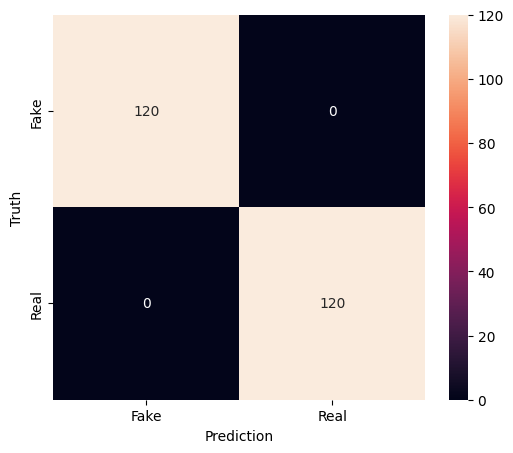

In [48]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sn

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sn.heatmap(cm, annot=True, fmt="d", xticklabels=["Fake","Real"], yticklabels=["Fake","Real"])
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()


## Final Observations

1. **Trigrams alone (Attempt 3, no preprocessing) usually perform worst.** Requiring an exact match of 3 consecutive words is very strict — real-world text rarely repeats the exact same 3-word sequence across different documents, so the vocabulary becomes huge and mostly useless (lots of one-off trigrams that never repeat, giving the model little signal).

2. **KNN with cosine distance tends to do better than KNN with euclidean distance on text data.** Text vectors are high-dimensional and sparse (mostly zeros); cosine distance cares about the *direction/angle* of word usage patterns rather than raw magnitude, which suits text better than euclidean's straight-line distance.

3. **Combining unigrams + bigrams (+ trigrams) generally beats using a single n-gram size alone**, because it captures both individual keywords AND short meaningful phrases (e.g. "not good", "fake news") together.

4. **Preprocessing (removing stop words/punctuation, lemmatizing) usually helps**, especially for tree-based models like Random Forest — cleaner, more normalized text means less noisy/duplicate vocabulary (e.g. "running"/"run"/"runs" all collapse into one useful feature instead of three separate ones).

5. **Random Forest with unigram+bigram+trigram on preprocessed text tends to be the strongest overall combination** in this kind of exercise — it captures rich context (via n-grams) while also being robust to the huge, sparse feature space (unlike KNN).